# A-SCLC

Edit the input path and device parameters, load the measurements, and inspect
the measured current density.
CSV format: `U(V),I(A),T(C)` with three numeric columns in that order (volts,
amperes, Celsius). Raw measurements retain their signs and order; measured
temperatures are available as `result.T_K`.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from asclc_workflow import run_calculation, export_results
from asclc_plotting import plot_measured_jv

## Input and device parameters

Example: MAPbBr3 S2, dark. Replace these values for your sample.

In [2]:
input_path = project_root / "data/MAPbBr3_S2_dark.csv"

device = dict(
    area=7.7e-6,          # m^2, converts measured I to J
    voltage_offset=0.0,   # V, added to measured U
)

In [3]:
result = run_calculation(input_path, device=device)
print(f"Loaded {result.V.size} measurements; "
      f"{(~result.measurements.finite).sum()} nonfinite rows retained.")

Loaded 214 measurements; 0 nonfinite rows retained.


## Measured current density

Measured current density against voltage on logarithmic axes. Nonpositive
readings are kept in the data but cannot appear on a logarithmic axis.

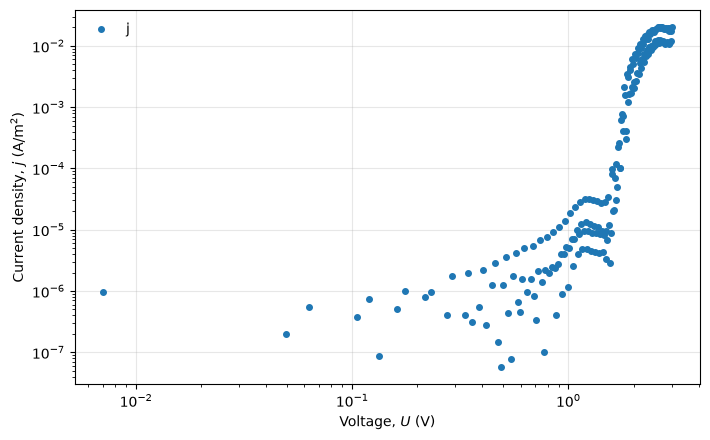

In [4]:
figures = {}
fig, ax = plot_measured_jv(result)
figures["measured_jv"] = fig

## Export

Save the figure as PNG/PDF/SVG and write the measured CSV to the output
directory.

In [5]:
output_dir = export_results(result, figures, project_root / "outputs")
print(f"Saved {len(figures)} figures and measured data to {output_dir}")

Saved 1 figures and measured data to C:\Work_coding\ASCLC_Pythonized\outputs
